In [1]:
# Import packages
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose 
import seaborn as sns

In [2]:
time_series_data = pd.read_csv("AirPassengers.csv")
time_series_data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
time_series_data.shape

(144, 2)

In [4]:
# Convert column year in datetime format
time_series_data['Month'] = pd.to_datetime(time_series_data['Month'])
time_series_data = time_series_data.set_index('Month')

In [5]:
time_series_data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, '#passenger')

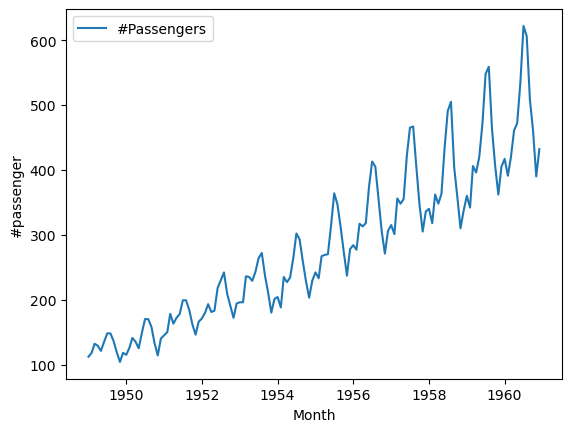

In [6]:
sns.lineplot(time_series_data)
plt.ylabel("#passenger")

In [7]:
#We can see that the number of passengers appears to be increasing over time, with some seasonality as well.

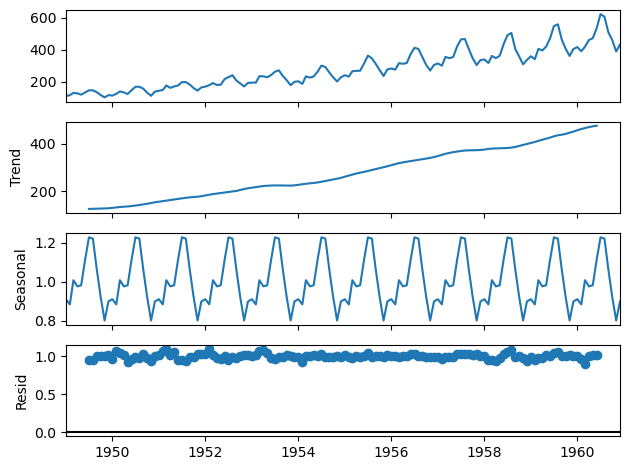

In [8]:
# Decomposition of time series - Multiplicative model
result = seasonal_decompose(time_series_data[['#Passengers']], model='multiplicative', period = 12)
result.plot()
plt.show()

In [9]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pymannkendall as mk

# Perform Mann-Kendall test
# H0: There is no monotonic trend in the series

mk.original_test(time_series_data['#Passengers'])

Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=14.381610025544802, Tau=0.8087606837606838, s=8327.0, var_s=335164.3333333333, slope=2.451216287678477, intercept=90.23803543098887)

In [11]:
#pvalue <0.5 => reject Ho. There is a trend present 

In [12]:
train_df=time_series_data[:int(time_series_data.shape[0]*0.7)]
test_df=time_series_data[int(time_series_data.shape[0]*0.7):]

In [13]:
train_df.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [14]:
train_df.shape

(100, 1)

In [15]:
test_df.shape

(44, 1)

In [16]:
#SINGLE EXPONENTIAL SMOOTHNING

from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [17]:
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single)

1957-05-01    348.0
1957-06-01    348.0
1957-07-01    348.0
1957-08-01    348.0
1957-09-01    348.0
1957-10-01    348.0
1957-11-01    348.0
1957-12-01    348.0
1958-01-01    348.0
1958-02-01    348.0
1958-03-01    348.0
1958-04-01    348.0
1958-05-01    348.0
1958-06-01    348.0
1958-07-01    348.0
1958-08-01    348.0
1958-09-01    348.0
1958-10-01    348.0
1958-11-01    348.0
1958-12-01    348.0
1959-01-01    348.0
1959-02-01    348.0
1959-03-01    348.0
1959-04-01    348.0
1959-05-01    348.0
1959-06-01    348.0
1959-07-01    348.0
1959-08-01    348.0
1959-09-01    348.0
1959-10-01    348.0
1959-11-01    348.0
1959-12-01    348.0
1960-01-01    348.0
1960-02-01    348.0
1960-03-01    348.0
1960-04-01    348.0
1960-05-01    348.0
1960-06-01    348.0
1960-07-01    348.0
1960-08-01    348.0
1960-09-01    348.0
1960-10-01    348.0
1960-11-01    348.0
1960-12-01    348.0
Freq: MS, dtype: float64


In [18]:
model_single_fit.params

{'smoothing_level': 0.9999999850984761,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.0,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

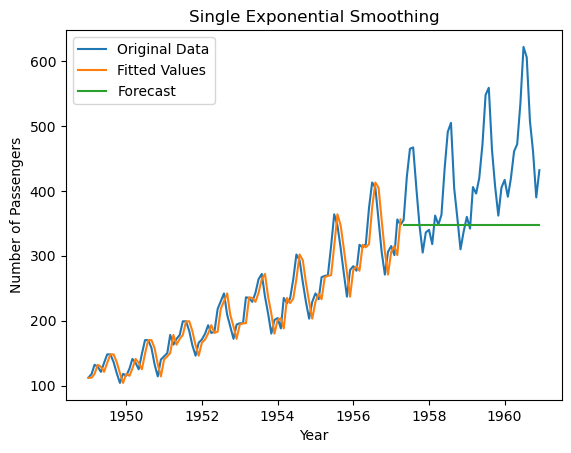

In [19]:
plt.plot(time_series_data, label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [20]:
#DOUBLE EXPONENTIAL SMOOTHNING

In [21]:
from statsmodels.tsa.api import Holt

model_double = Holt(train_df)
model_double_fit = model_double.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [22]:
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double)

1957-05-01    352.149928
1957-06-01    356.289994
1957-07-01    360.430061
1957-08-01    364.570127
1957-09-01    368.710193
1957-10-01    372.850259
1957-11-01    376.990326
1957-12-01    381.130392
1958-01-01    385.270458
1958-02-01    389.410524
1958-03-01    393.550591
1958-04-01    397.690657
1958-05-01    401.830723
1958-06-01    405.970789
1958-07-01    410.110856
1958-08-01    414.250922
1958-09-01    418.390988
1958-10-01    422.531054
1958-11-01    426.671121
1958-12-01    430.811187
1959-01-01    434.951253
1959-02-01    439.091320
1959-03-01    443.231386
1959-04-01    447.371452
1959-05-01    451.511518
1959-06-01    455.651585
1959-07-01    459.791651
1959-08-01    463.931717
1959-09-01    468.071783
1959-10-01    472.211850
1959-11-01    476.351916
1959-12-01    480.491982
1960-01-01    484.632048
1960-02-01    488.772115
1960-03-01    492.912181
1960-04-01    497.052247
1960-05-01    501.192313
1960-06-01    505.332380
1960-07-01    509.472446
1960-08-01    513.612512


In [23]:
model_double_fit.params

{'smoothing_level': 0.999190910127339,
 'smoothing_trend': 0.007412899330137531,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.0,
 'initial_trend': 6.0,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

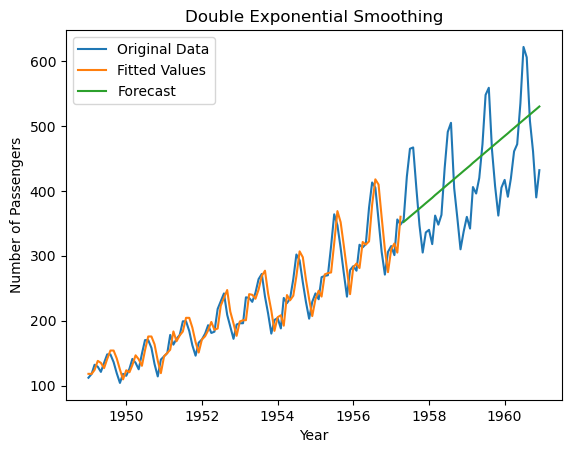

In [24]:
plt.plot(time_series_data, label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

In [25]:
#TRIPLE EXPONENTIAL SMOOTHNING

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

# Create an instance of ExponentialSmoothing class
model_triple = ExponentialSmoothing(train_df, seasonal_periods=12, trend='add', seasonal='add')

# Fit the model to the data
model_triple_fit = model_triple.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:
model_triple_fit.params

{'smoothing_level': 0.2550250780260589,
 'smoothing_trend': 1.800645950512257e-09,
 'smoothing_seasonal': 0.7449749171421274,
 'damping_trend': nan,
 'initial_level': 118.7941010710188,
 'initial_trend': 2.3251129433904585,
 'initial_seasons': array([ -9.11783738,  -3.51563904,   8.9645761 ,   3.69243412,
         -5.06898002,   9.03423164,  21.25027253,  18.82286355,
          4.68963164, -14.11839322, -28.56031593, -11.9475752 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [28]:
forecast_triple = model_triple_fit.forecast(len(test_df))

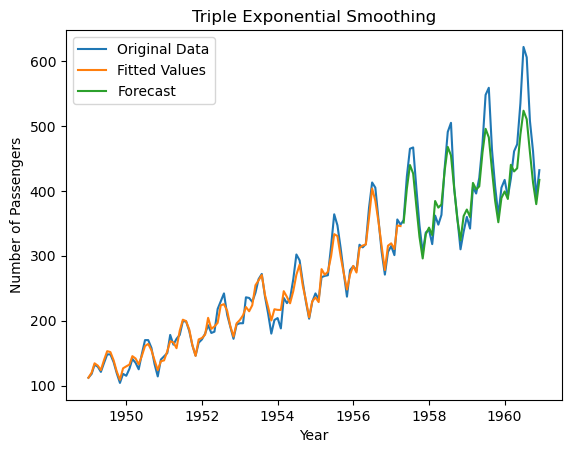

In [29]:
plt.plot(time_series_data, label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [30]:
from statsmodels.tsa.api import ExponentialSmoothing

# Create an instance of ExponentialSmoothing class
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods=12, trend='add', seasonal='mul')

# Fit the model to the data
model_triple_fit_mul = model_triple_mul.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [31]:
model_triple_fit_mul.params

{'smoothing_level': 0.7295083054615172,
 'smoothing_trend': 0.0,
 'smoothing_seasonal': 0.0,
 'damping_trend': nan,
 'initial_level': 107.47631192392862,
 'initial_trend': 1.9744279071687116,
 'initial_seasons': array([1.0356126 , 1.00574291, 1.1597878 , 1.12207221, 1.11389086,
        1.25654266, 1.38869172, 1.35897979, 1.19435843, 1.03748427,
        0.90165744, 1.01933521]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [32]:
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))

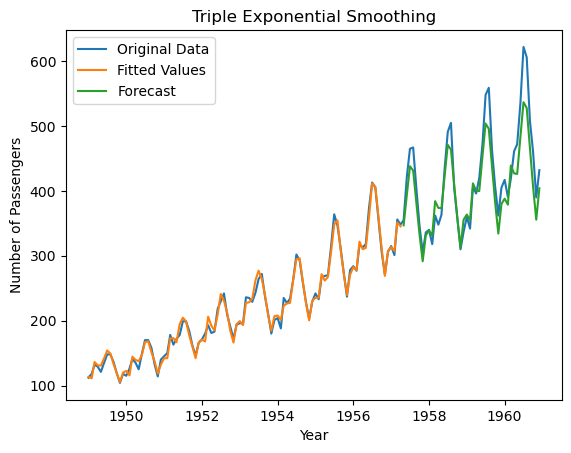

In [33]:
plt.plot(time_series_data, label='Original Data')
plt.plot(model_triple_fit_mul.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple_mul, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [34]:
residuals_add = model_triple_fit.resid
residuals_add.head()

Month
1949-01-01   -0.001377
1949-02-01   -1.928337
1949-03-01   -2.241891
1949-04-01   -1.723123
1949-05-01   -2.847382
dtype: float64

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test_add = mean_absolute_percentage_error(test_df['#Passengers'],forecast_triple)
print('MAPE for Test Data:', mape_test_add)

MAPE for Test Data: 0.05397259855132907


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test_mul = mean_absolute_percentage_error(test_df['#Passengers'],forecast_triple_mul)
print('MAPE for Test Data:', mape_test_mul)

MAPE for Test Data: 0.05580323577135992


In [37]:
#ADF TEST
#Null Hypothesis (HO): Series is non-stationary, i.e, series has a unit root.
#Alternate Hypothesis(HA): Series is stationary, i.e, series has no unit root.
#p-value < 0.05 – Reject Null Hypothesis(HO)

In [38]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(time_series_data['#Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060597
p-value: 0.9918802434376411


In [39]:
#p-value > 0.05 – Do not Reject Null Hypothesis(HO). Series is non-stationary

In [40]:
#KPSS TEST
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.
#p-value < 0.05 –  Reject Null Hypothesis(HO)

In [41]:
from statsmodels.tsa.stattools import kpss
kp = kpss(time_series_data['#Passengers'])
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.01


C:\Users\Tanvi.Koyande\AppData\Local\Temp\ipykernel_14512\4161866113.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(time_series_data['#Passengers'])


In [42]:
#Here p-value is less than 0.05 so reject Null Hypothesis i.e data is NOT trend stationary

In [43]:
#Here both the condition is not satisfied i.e Series is NOT stationary

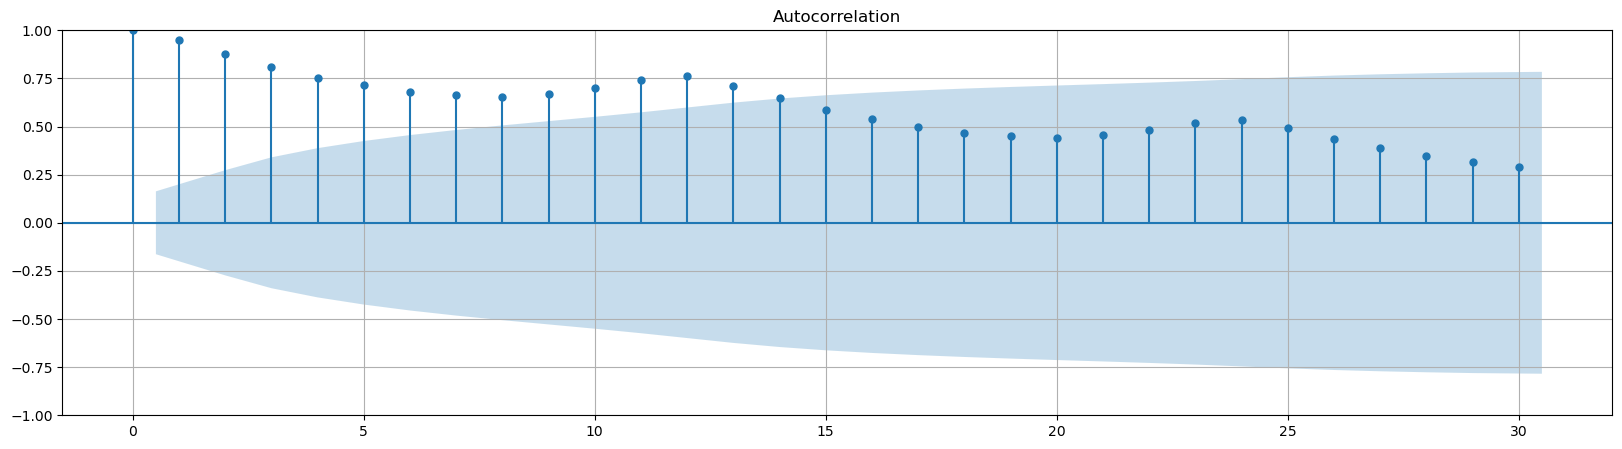

In [44]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(time_series_data['#Passengers'] , ax=plt.gca(), lags =30 )
plt.show()

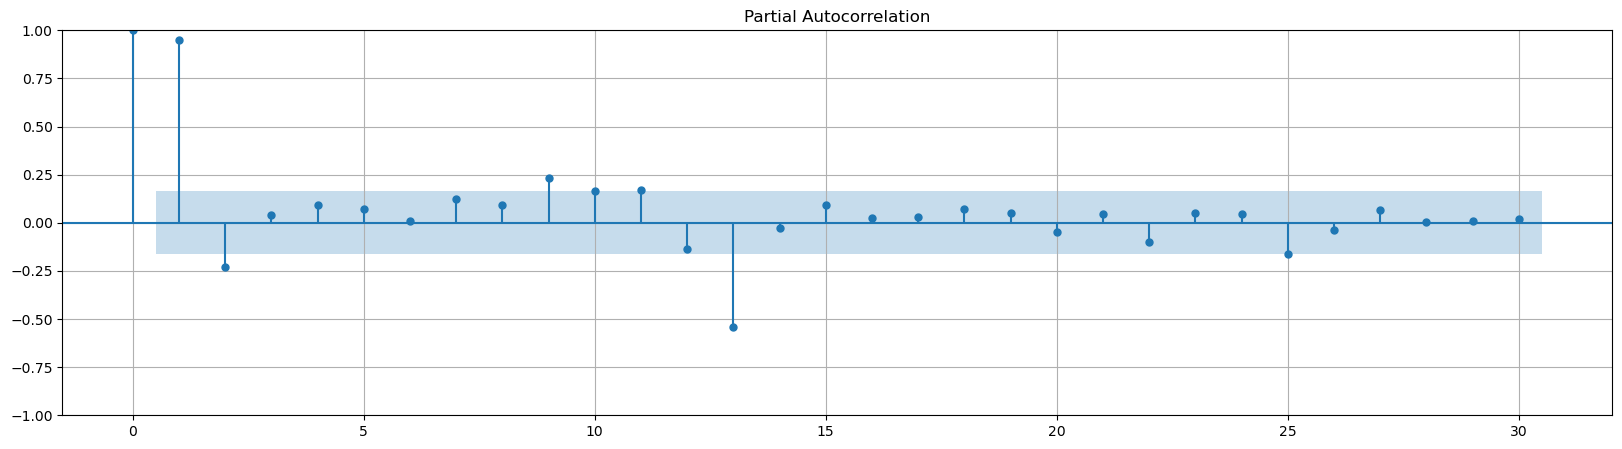

In [45]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(time_series_data['#Passengers'] , ax=plt.gca(), lags = 30)
plt.show()

In [46]:
#With the help of ACF and PACF we can see that values of lag are falling outside the significant region so we can conclude that our data is non-stationary

In [47]:
#So to make the data stationary we do differencing

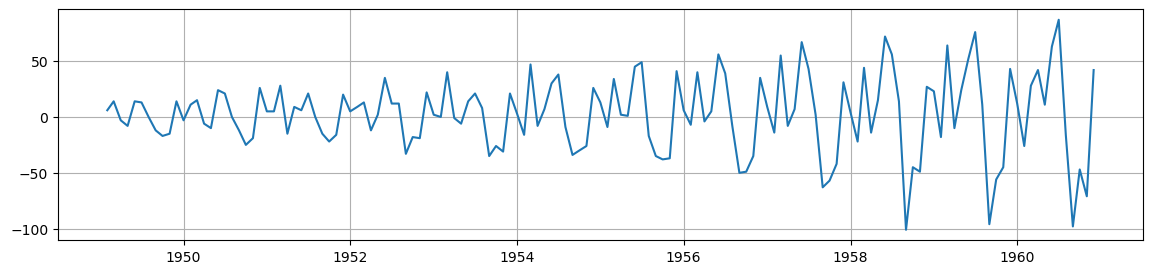

In [48]:
#NON-SEASONAL DIFFERENCING
diff = time_series_data['#Passengers'].diff().dropna()     # TRYING TO MAKE DATA TREND STATIONARY
plt.figure(figsize=(14, 3))
plt.grid()
plt.plot(diff)
plt.show()

In [49]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.829266824169992
p-value: 0.0542132902838265


In [50]:
#p-value > 0.05 – Do not Reject Null Hypothesis(HO). Series is non-stationary

In [51]:
from statsmodels.tsa.stattools import kpss
kp = kpss(diff)
p = kp[1]
print("p-value for KPSS test (untransformed) = ", p)


p-value for KPSS test (untransformed) =  0.1


C:\Users\Tanvi.Koyande\AppData\Local\Temp\ipykernel_14512\4268959832.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


In [52]:
#Here p-value is more than 0.05 so accept Null Hypothesis i.e data is trend stationary

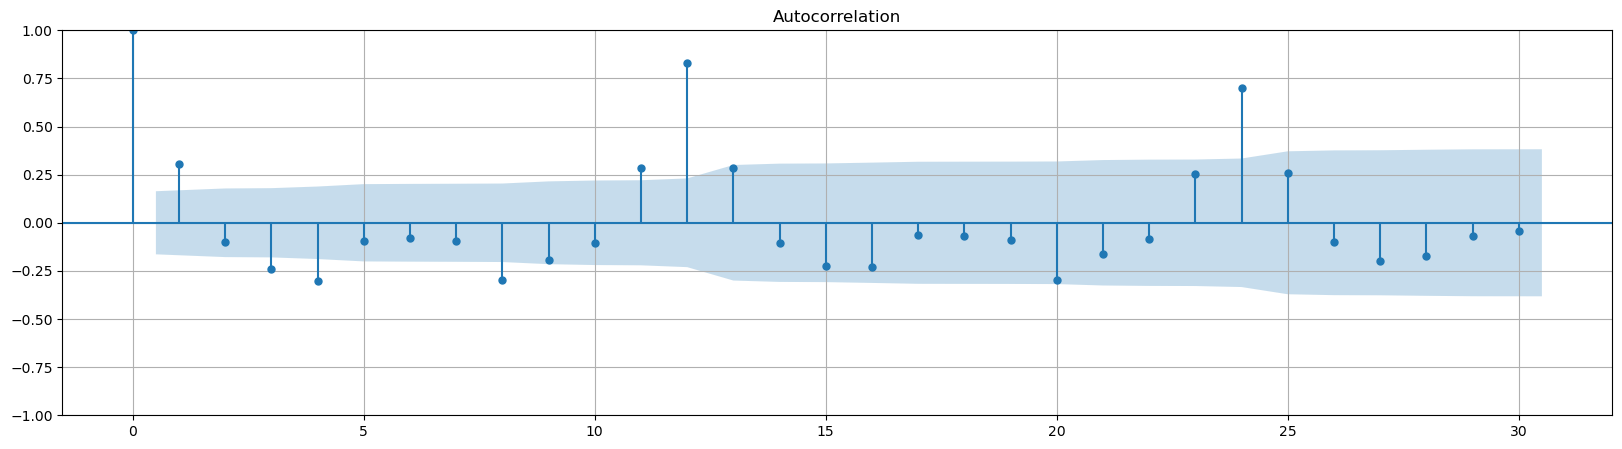

In [53]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(diff, ax=plt.gca(), lags =30 )
plt.show()

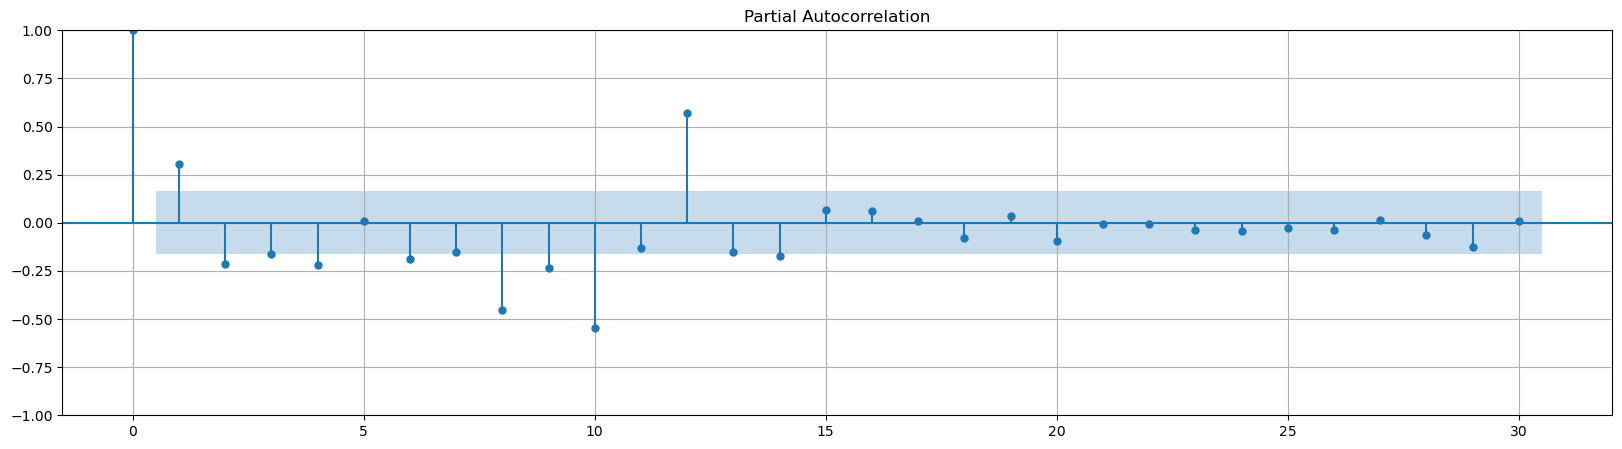

In [54]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(diff , ax=plt.gca(), lags = 30)
plt.show()

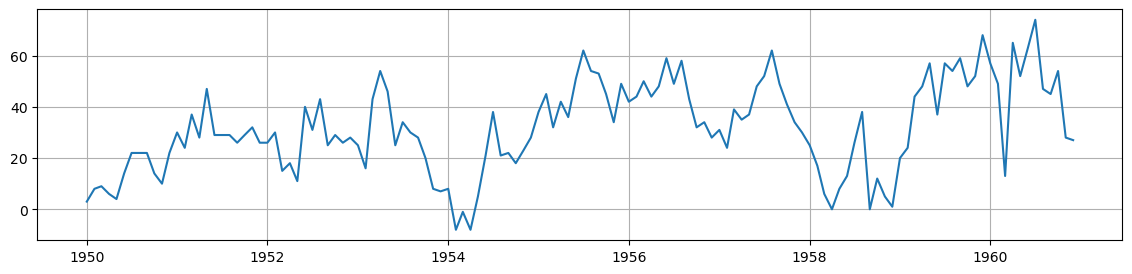

In [55]:
#SEASONAL DIFFERENCING
sdiff = time_series_data['#Passengers'].diff(periods = 12).dropna()          # TRYING TO REMOVE SEASONALITY
plt.figure(figsize=(14, 3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [56]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(sdiff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.3830207264924805
p-value: 0.011551493085514982


In [57]:
#p-value < 0.05 – Reject Null Hypothesis(HO). Series is stationary

In [58]:
#KPSS TEST
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.
#p-value < 0.05 –  Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import kpss
kp = kpss(sdiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.03409999422360403


In [59]:
#p-value < 0.05 – Reject Null Hypothesis(HO). Series is not stationary

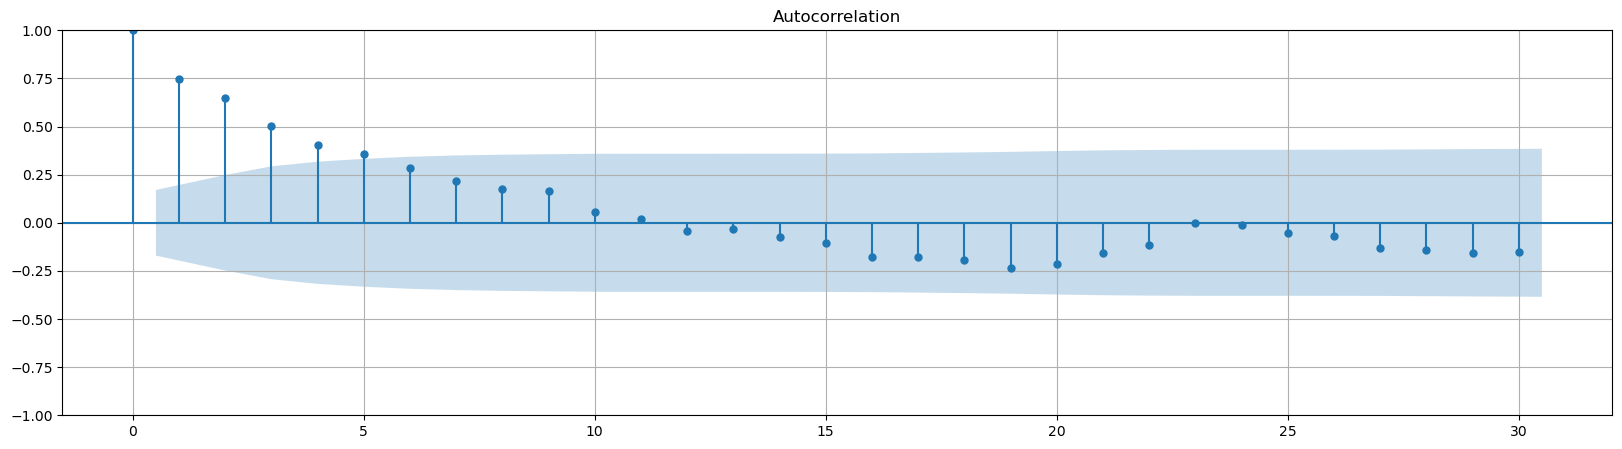

In [60]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(sdiff, ax=plt.gca(), lags =30 )
plt.show()

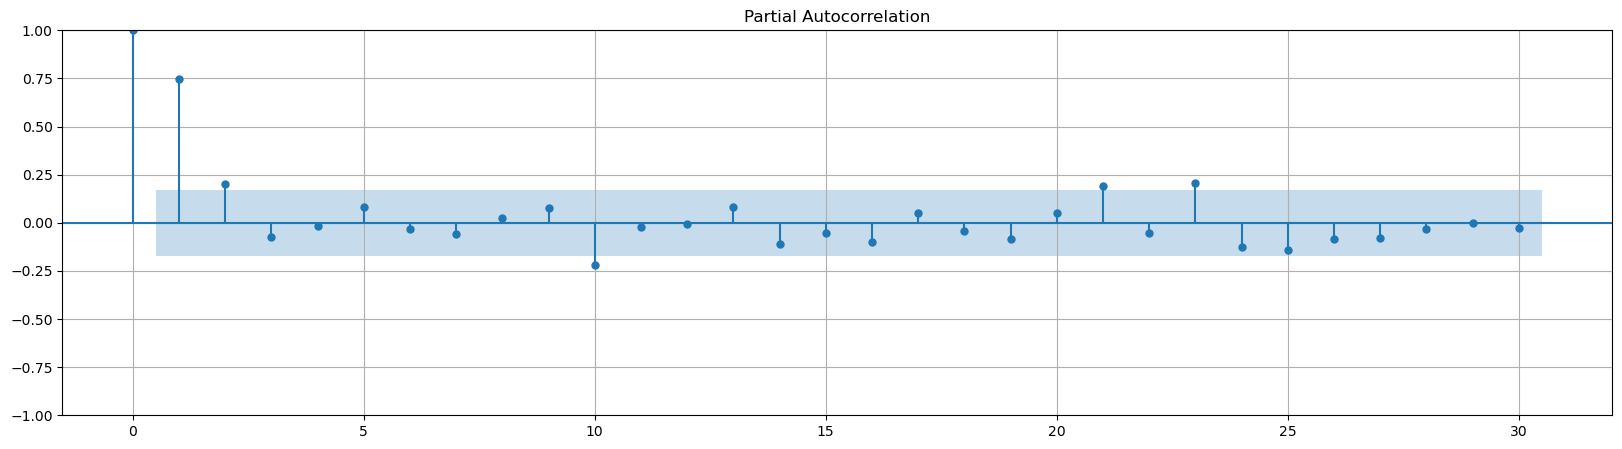

In [61]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(sdiff , ax=plt.gca(), lags = 30)
plt.show()

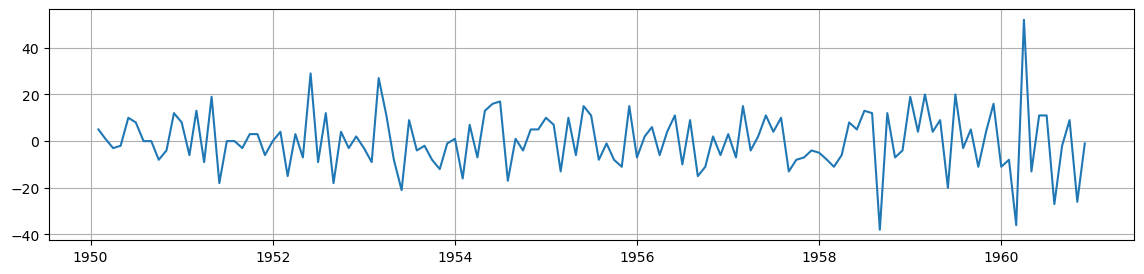

In [62]:
#SEASONAL AND NON-SEASONAL DIFFERENCING
sdiff = time_series_data['#Passengers'].diff(periods = 12).dropna()  # seasonal differencing
sddiff = sdiff.diff().dropna()                          # non-seasonal differencing  # 1ST ORDER DIFFERENCING
plt.figure(figsize=(14, 3))
plt.grid()
plt.plot(sddiff)

plt.show()

In [63]:
#ADF
#Null Hypothesis (HO): Series is non-stationary, or series has a unit root.
#Alternate Hypothesis(HA): Series is stationary, or series has no unit root.
#p-value < 0.05 – Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import adfuller
result = adfuller(sddiff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.595618083746338
p-value: 1.856511600123444e-28


In [64]:
## SERIES IS STATIONARY

In [65]:
#KPSS TEST
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.
#p-value < 0.05 –  Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import kpss
kp = kpss(sddiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.1


C:\Users\Tanvi.Koyande\AppData\Local\Temp\ipykernel_14512\2026258703.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


In [66]:
## Data is trend stationary

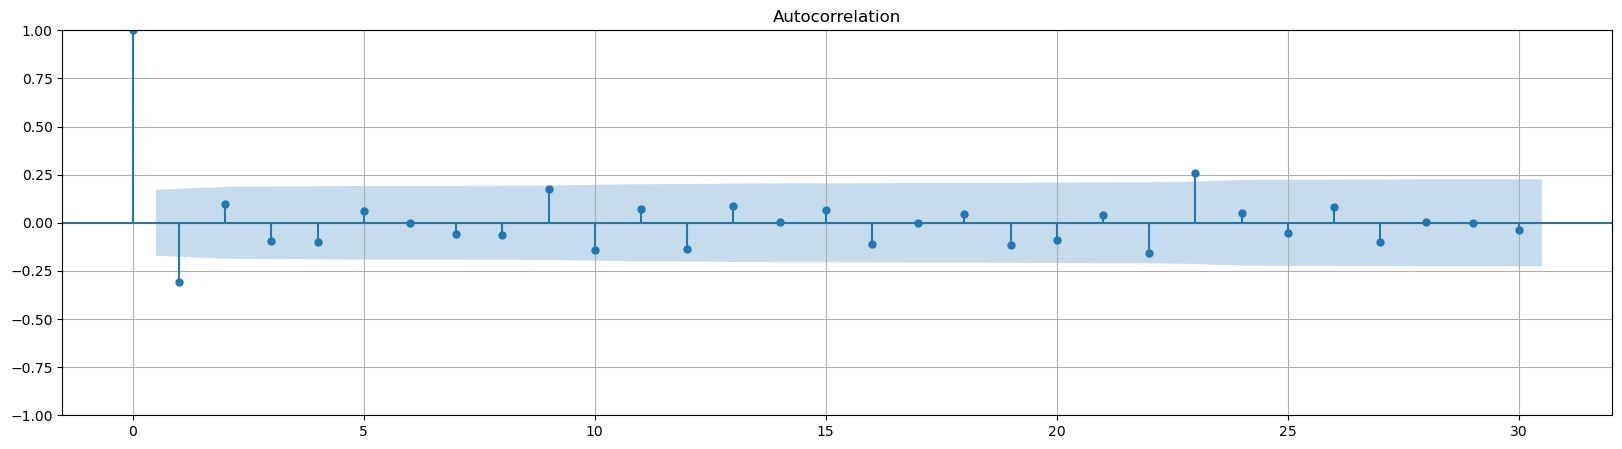

In [67]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(sddiff , ax=plt.gca(), lags = 30)
plt.show()

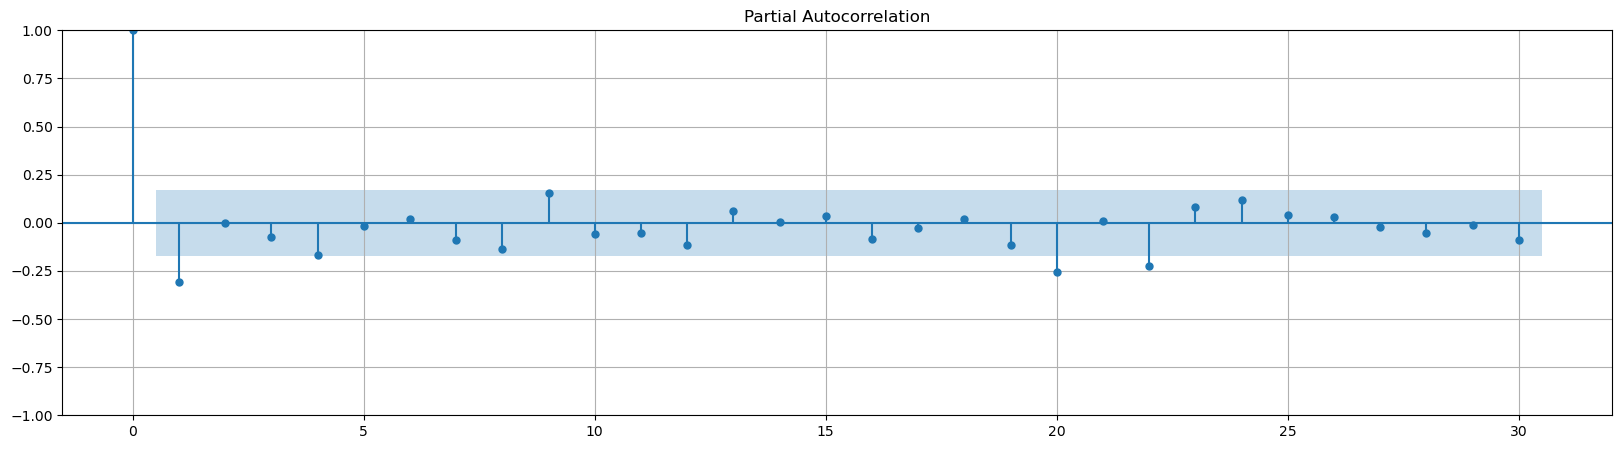

In [68]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(sddiff , ax=plt.gca(), lags = 30)
plt.show()

In [69]:
#The ACF and PACF graphs also give the same result that the data is stationory after first order differencing. d = 1